# Example

<IPython.core.display.Javascript object>


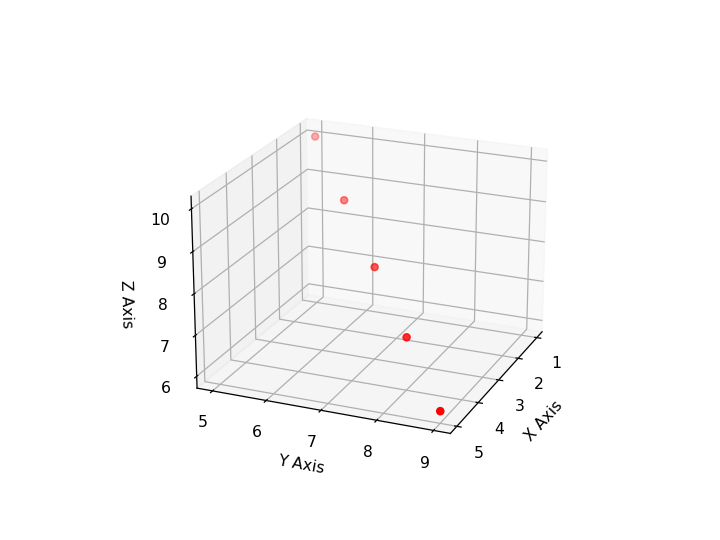

In [34]:

%matplotlib notebook

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = [1, 2, 3, 4, 5]
y = [5, 6, 7, 8, 9]
z = [10, 9, 8, 7, 6]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='r', marker='o')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.show()


# Implementation

In [10]:
import json

with open('my_project/controllers/my_controller/learnt_policies.json', 'r') as f:
    data = json.load(f)

all_trajectories = []

for policy in data:
    trajectory = [policy["Coordinates"][0]] +  policy["SetPairs"][1:] +[policy["Coordinates"][1]]
    
    all_trajectories.append(trajectory)
    
print(all_trajectories)

[[[0, 9], [15, 8], [4, 9], [7, 8], [2, 7], [10, 15], [11, 16], [10, 5], [16, 3], [10, 6], [7, 4], [18, 5]], [[9, 10], [9, 8], [9, 10], [8, 5], [16, 3], [3, 5], [8, 4], [6, 7], [9, 2], [9, 8], [5, 2], [7, 3]]]


In [11]:
from minisom import MiniSom
import pickle
import csv
import numpy as np

with open('my_project/controllers/my_controller/somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)

gps_data=[]
with open("my_project/controllers/my_controller/gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
   
    for row in gps_reader:
        gps_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
                

weights_som = somVisual.get_weights()

def get_coordinate(input):
    som_winner =weights_som[input[0], input[1]]
    return som_winner

#denormalize a vector given dataset
def denormalize_vector(normalized_vector, data):
    # Calculate min and max for each feature in the dataset
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    # Denormalize the vector
    denormalized_vector = []
    for i in range(len(normalized_vector)):
        denormalized_value = normalized_vector[i] * (max_values[i] - min_values[i]) + min_values[i]
        denormalized_vector.append(denormalized_value)
    return denormalized_vector



all_coordinates= []
for trajectory in all_trajectories:
    new_coordinates=[]
    for coordinate in trajectory:
        new_coord=get_coordinate(coordinate)
        new_coord=list(new_coord)
        new_coord=denormalize_vector(new_coord, gps_data)
        new_coordinates.append(new_coord) 
    all_coordinates.append(new_coordinates)
    
print(all_coordinates)

[[[0.22670323731255443, -0.09065590224897171, 0.08105997699588968], [0.2005646687000519, -0.18557921902997482, 0.1313352689986276], [0.23295966249961894, -0.13439038609428397, 0.08226129135388571], [0.22513000126628335, -0.1549865948373052, 0.10715620126829559], [0.2302524304963236, -0.10298438341329677, 0.10229603774413715], [0.2001366200756473, -0.16629100515438944, 0.04296375201263658], [0.19253682453413468, -0.16868846371164004, 0.02108901050416316], [0.21990274344860256, -0.15214481163542956, 0.14650943460433585], [0.18925537112703708, -0.1637647039489232, 0.19105677151846412], [0.21705795077866885, -0.1528160750912514, 0.1304381685244839], [0.22376535711353907, -0.13223663476516814, 0.13249149871013138], [0.18654016431005896, -0.18932117219711, 0.17721616406193536]], [[0.21478657176383287, -0.15725196461476454, 0.09066894922305879], [0.21337303851490313, -0.14783154093307777, 0.10923773849000648], [0.21478657176383287, -0.15725196461476454, 0.09066894922305879], [0.22540406412414

<IPython.core.display.Javascript object>


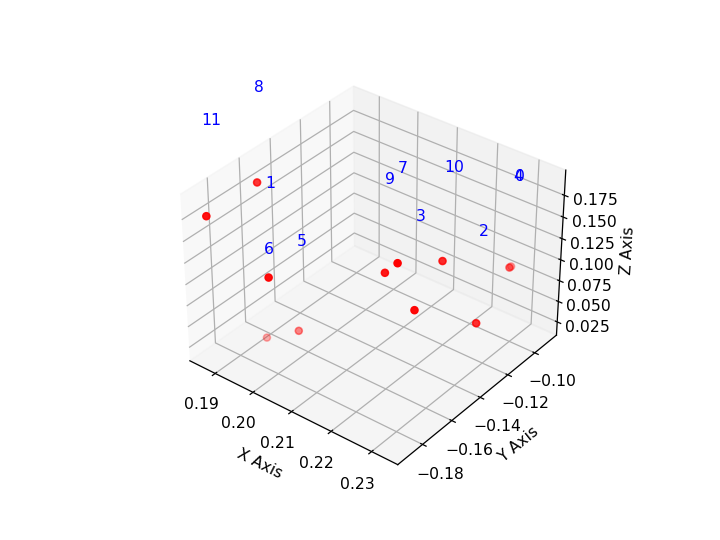

<IPython.core.display.Javascript object>


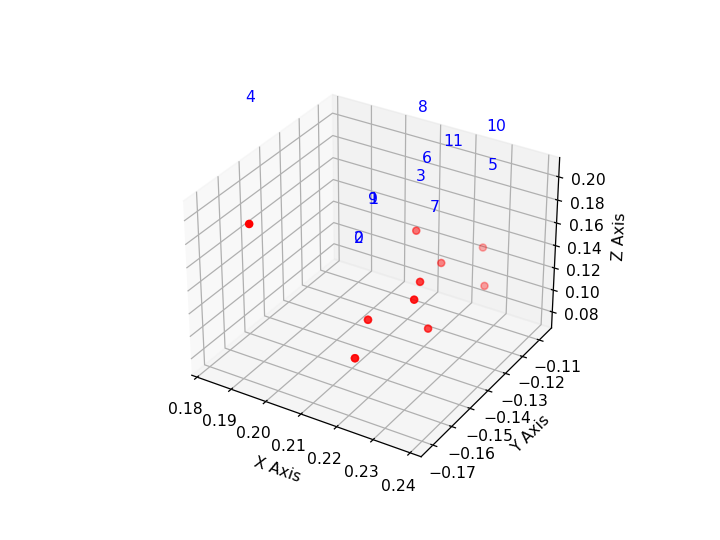

In [12]:
%matplotlib notebook

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

for i in range(len(all_coordinates)):
    trajectory_to_plot= all_coordinates[i]

    x = []
    y = []
    z = []

    for coordinate in trajectory_to_plot:
        x.append(coordinate[0])
        y.append(coordinate[1])
        z.append(coordinate[2])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x, y, z, c='r', marker='o')
    
    for index, (x_coord, y_coord, z_coord) in enumerate(trajectory_to_plot):
        ax.text(x_coord, y_coord, z_coord + 0.1, str(index), color='blue')  # Adjust z + 0.1 to position text above the point


    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')

    plt.show()

In [15]:
import math

# Lista de coordenadas tridimensionales
coordenadas =[[0.22670323731255443, -0.09065590224897171, 0.08105997699588968], [0.2005646687000519, -0.18557921902997482, 0.1313352689986276], [0.23295966249961894, -0.13439038609428397, 0.08226129135388571], [0.22513000126628335, -0.1549865948373052, 0.10715620126829559], [0.2302524304963236, -0.10298438341329677, 0.10229603774413715], [0.2001366200756473, -0.16629100515438944, 0.04296375201263658], [0.19253682453413468, -0.16868846371164004, 0.02108901050416316], [0.21990274344860256, -0.15214481163542956, 0.14650943460433585], [0.18925537112703708, -0.1637647039489232, 0.19105677151846412], [0.21705795077866885, -0.1528160750912514, 0.1304381685244839], [0.22376535711353907, -0.13223663476516814, 0.13249149871013138], [0.18654016431005896, -0.18932117219711, 0.17721616406193536]]
# Tomamos la última coordenada como referencia
ultima_coordenada = coordenadas[-1]

# Función para calcular la distancia euclidiana
def distancia_euclidiana(coord1, coord2):
    return math.sqrt(sum((c1 - c2)**2 for c1, c2 in zip(coord1, coord2)))

# Calcular y mostrar la distancia euclidiana de cada coordenada a la última
for i, coord in enumerate(coordenadas[:-1]):  # Excluimos la última coordenada
    distancia = distancia_euclidiana(coord, ultima_coordenada)
    print(f"Distancia de la coordenada {i+1} a la última coordenada: {distancia:.6f}")


Distancia de la coordenada 1 a la última coordenada: 0.143506
Distancia de la coordenada 2 a la última coordenada: 0.048122
Distancia de la coordenada 3 a la última coordenada: 0.119116
Distancia de la coordenada 4 a la última coordenada: 0.087043
Distancia de la coordenada 5 a la última coordenada: 0.122384
Distancia de la coordenada 6 a la última coordenada: 0.136890
Distancia de la coordenada 7 a la última coordenada: 0.157599
Distancia de la coordenada 8 a la última coordenada: 0.058635
Distancia de la coordenada 9 a la última coordenada: 0.029190
Distancia de la coordenada 10 a la última coordenada: 0.066724
Distancia de la coordenada 11 a la última coordenada: 0.081515
